In [1]:
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt

In [2]:
from src.estimalign import estimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step

# Data

In [3]:
positive_id_tuples = []
close_negative_id_tuples = []
with open('./Proteomes/human_to_chicken_upto1000aa.blast') as h:
    for l in h:
        l = l.split('\t')
        evalue = float(l[-2])
        if evalue == 0:
            positive_id_tuples.append([l[0], l[1]])
        elif evalue > 0.0001:
            close_negative_id_tuples.append([l[0], l[1]])

In [4]:
human_proteome = list(SeqIO.parse('Proteomes/GCF_000001405.40/up_to_1000.faa', 'fasta'))
chick_proteome = list(SeqIO.parse('Proteomes/GCF_016699485.2/up_to_1000.faa', 'fasta'))

In [5]:
human_prot_ids = [seq.id for seq in human_proteome]
chick_prot_ids = [seq.id for seq in chick_proteome]

In [6]:
SETSIZE = 1000

In [7]:
prot_dset = rd.choice(len(positive_id_tuples), SETSIZE, replace=False)
prot_dset = [positive_id_tuples[i] for i in prot_dset]

In [8]:
human_list = [human_proteome[human_prot_ids.index(hpid)] for hpid, cpid in prot_dset]
chick_list = [chick_proteome[chick_prot_ids.index(cpid)] for hpid, cpid in prot_dset]

In [9]:
from miRBench.dataset import list_datasets, get_dataset_df

In [10]:
hejret_train = get_dataset_df(list_datasets()[0], split="train")
hejret_test = get_dataset_df(list_datasets()[0], split="test")

Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


In [11]:
mirlist = hejret_train['noncodingRNA']
mirlist = [Seq(seq) for seq in mirlist]
genelist = hejret_train['gene']
genelist = [Seq(seq).reverse_complement() for seq in genelist]

In [12]:
hejret_train

,gene,noncodingRNA,noncodingRNA_name,noncodingRNA_fam,feature,label,chr,start,end,strand,gene_cluster_ID
0,CCCAGGGTGTTTCATGCTGAGGTAGTAGGATGAATAAAGGCAAATA...,CTATACAATCTACTGTCTTTC,hsa-let-7a-3p,let-7,NaN,1,13,103634174,103634223,-,355
1,CAACTCTATACAACACACCTACTATCTCTTGATGCCCTATTGACAG...,TGAGGTAGTAGGTTGTGTGGTT,hsa-let-7a-5p,let-7,exon,1,10,102362496,102362545,+,1611
2,TAGAGGATCCTAGACCAGCATGCCAGTGTGCCAAGGCCACAGGGAA...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,11,65500706,65500755,+,1457
3,CATCCCCCTGACGGCCGAGAAGCTGTGCATCTACACCGACAACTCC...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,11,69643180,69643229,+,97
4,CAACATGAAACAGTTCATCCGCTACCTCATCTCGTCCAACGTCGGG...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,12,110342392,110342441,+,3303
...,...,...,...,...,...,...,...,...,...,...,...
8188,TGATAGTTCAGCTTGAATGTCTCTTAGAGGGTGGGCTTTTGTTGAT...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,exon,0,11,65502560,65502609,+,2508
8189,GTGGGACTGCTCTGTCCCCTGCCCCTACTGCAGAGATAGCACTGCC...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,three_prime_utr,0,17,49053543,49053592,+,239
8190,CCATTTCTTTGGATTTGCCTCTCCTGGACATTTCATATAGATGAAA...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,intron,0,15,101365823,101365872,-,423
8191,CATCACATGCAGGTGGGCCTGGGCTCCTTGGGAGGAAGTATGGTGG...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,"intron,exon",0,17,1651376,1651425,-,65


In [13]:
const_step = create_constant_step(0.00001)


In [16]:
params = estimalign(mirlist, genelist, hejret_train['label'],
                    verbose=True, substitution_mode='simple',
                    aligner_mode='local',
                    gap_mode = 'affine',
                    stepfunction = const_step,
                    max_iter=50, 
                   num_threads=16)

Alphabet:
ATGC
Initial parameters:
{'alpha': -4.821011324003074, 'match_score': 0.654279646243572, 'mismatch_score': -0.5895459737194781, 'open_gap_score': -1.1435240101030584, 'extend_gap_score': -0.0922643443795387}
Start of iteration 0
Current alpha: -4.821011324003074
Current logL: -4130.170195008038
Updated alpha: -4.8682587471855046
Updated logL: -4128.61763368241
New subgradient:
{'Substitutions': Array([[ -43.99139974,   -0.60533775,  -13.61174739,   -9.34432639],
       [  15.69450418, -199.16031753,   -1.31666106,   82.92884591],
       [  76.82516036,  -31.63232867,  -39.69744625,  -67.65037564],
       [ -37.79191529,  -64.13577527,  -81.19046269,  -13.45833428]],
         alphabet='ATGC'), 'Gap opens': -109.19253679883614, 'Gap extends': -451.3449508598211}
Stepsize: 1e-05
Gap open step: -0.0010919253679883615
Gap extend step: -0.004513449508598211
Match step: -0.0029630749779525852
Mismatch step: -0.0013183041970109997
New parameters:
{'alpha': -4.8682587471855046, 'match

Updated alpha: -4.58788683221514
Updated logL: -4112.462745699069
New subgradient:
{'Substitutions': Array([[  13.31669807,  -11.78262869,  -17.3270948 ,   -2.97549322],
       [   8.38124197, -194.94214272,   -1.36286978,   83.63728405],
       [  78.45894966,  -31.5739946 ,   51.55131758,  -78.09340395],
       [ -38.93460014,  -66.36091216,  -77.57391368,  107.24863519]],
         alphabet='ATGC'), 'Gap opens': -19.988455018273708, 'Gap extends': -206.00296542378655}
Stepsize: 1e-05
Gap open step: -0.0001998845501827371
Gap extend step: -0.002060029654237866
Match step: -0.0002282549188493367
Mismatch step: -0.0015550743535129052
New parameters:
{'alpha': -4.58788683221514, 'match_score': 0.6405409178765556, 'mismatch_score': -0.6022512751773335, 'open_gap_score': -1.1493840098348815, 'extend_gap_score': -0.12424858798989845}
Subgradient norm: 259.8852162527455
End of iteration 8

Start of iteration 9
Current alpha: -4.58788683221514
Current logL: -4111.9001853889495
Updated alpha: 

Updated alpha: -4.576215841694481
Updated logL: -4108.168400431271
New subgradient:
{'Substitutions': Array([[  39.77854487,   -8.50852585,  -16.7694182 ,   -0.93664763],
       [  11.12639007, -184.06727257,   -0.41614256,   88.36163008],
       [  77.74642469,  -28.59188587,   76.69177336,  -69.84443737],
       [ -38.19187371,  -65.19096693,  -74.2898775 ,  134.2876733 ]],
         alphabet='ATGC'), 'Gap opens': 9.951079251294463, 'Gap extends': -130.59878296315452}
Stepsize: 1e-05
Gap open step: 9.951079251294463e-05
Gap extend step: -0.0013059878296315453
Match step: 0.0006669071896434099
Mismatch step: -0.0012550533078700217
New parameters:
{'alpha': -4.576215841694481, 'match_score': 0.6450576160616147, 'mismatch_score': -0.6147098217095789, 'open_gap_score': -1.148934249469031, 'extend_gap_score': -0.13760546948972832}
Subgradient norm: 193.27262129349367
End of iteration 17

Start of iteration 18
Current alpha: -4.576215841694481
Current logL: -4107.795543678987
Updated alpha:

Updated alpha: -4.606684315644357
Updated logL: -4105.326929021084
New subgradient:
{'Substitutions': Array([[  40.39367398,   -6.71929101,  -18.74378893,    4.33341671],
       [  12.81528681, -180.01248527,   -2.04845532,   87.20789102],
       [  77.7221262 ,  -26.93032207,   73.25661652,  -69.03640116],
       [ -32.84351146,  -60.93135448,  -74.45228569,  132.07950845]],
         alphabet='ATGC'), 'Gap opens': 9.033091083737068, 'Gap extends': -82.58849671907633}
Stepsize: 1e-05
Gap open step: 9.033091083737068e-05
Gap extend step: -0.0008258849671907634
Match step: 0.0006571731367289495
Mismatch step: -0.0010962668939821572
New parameters:
{'alpha': -4.606684315644357, 'match_score': 0.6509733921161326, 'mismatch_score': -0.6252452982214387, 'open_gap_score': -1.1480843612750804, 'extend_gap_score': -0.1473742925744536}
Subgradient norm: 152.44419591981352
End of iteration 26

Start of iteration 27
Current alpha: -4.606684315644357
Current logL: -4105.106667588237
Updated alpha: 

Updated alpha: -4.630495635631117
Updated logL: -4103.5440069616
New subgradient:
{'Substitutions': Array([[  39.99146632,   -6.58949423,  -15.14392277,    4.23175846],
       [  17.35969115, -184.12919854,   -1.19221637,   83.8003474 ],
       [  76.98825681,  -27.23112825,   61.98812508,  -66.40289757],
       [ -32.3204008 ,  -59.97713153,  -71.56152133,  127.01444847]],
         alphabet='ATGC'), 'Gap opens': -0.03641961496113777, 'Gap extends': -68.22214648183956}
Stepsize: 1e-05
Gap open step: -3.6419614961137774e-07
Gap extend step: -0.0006822214648183957
Match step: 0.0004486484132279003
Mismatch step: -0.000980386590431707
New parameters:
{'alpha': -4.630495635631117, 'match_score': 0.6554127770962402, 'mismatch_score': -0.634708736666679, 'open_gap_score': -1.147826352285426, 'extend_gap_score': -0.15418388438285419}
Subgradient norm: 127.58799022980232
End of iteration 35

Start of iteration 36
Current alpha: -4.630495635631117
Current logL: -4103.386257285937
Updated alpha:

Current alpha: -4.6507489517848954
Current logL: -4102.341619771349
Updated alpha: -4.654018162591306
Updated logL: -4102.33415886784
New subgradient:
{'Substitutions': Array([[  43.31719319,   -5.52840241,  -14.71653485,    3.16294287],
       [  18.14079249, -181.26583796,    1.04393141,   86.38687898],
       [  78.25484894,  -28.79240437,   59.32367275,  -64.61827938],
       [ -31.24096618,  -61.24750869,  -71.50100302,  123.51548402]],
         alphabet='ATGC'), 'Gap opens': 2.1506683548906746, 'Gap extends': -39.446913159343715}
Stepsize: 1e-05
Gap open step: 2.1506683548906747e-05
Gap extend step: -0.0003944691315934372
Match step: 0.0004489051199972824
Mismatch step: -0.0009065570421417915
New parameters:
{'alpha': -4.654018162591306, 'match_score': 0.6594908220254702, 'mismatch_score': -0.6431403583187859, 'open_gap_score': -1.1477836247836932, 'extend_gap_score': -0.15838873069328843}
Subgradient norm: 108.60156125185317
End of iteration 44

Start of iteration 45
Current alp

In [17]:
params['match_score']

0.6612810167438959

In [19]:
params.keys()

dict_keys(['open_gap_score', 'extend_gap_score', 'match_score', 'mismatch_score', 'loglik_trajectory', 'subgradient_l2_trajectory', 'final_loglik', 'aligner', 'alignments', 'alignment_logit_scores', 'alpha', 'loglik_expectation_trajectory', 'loglik_sd_trajectory'])

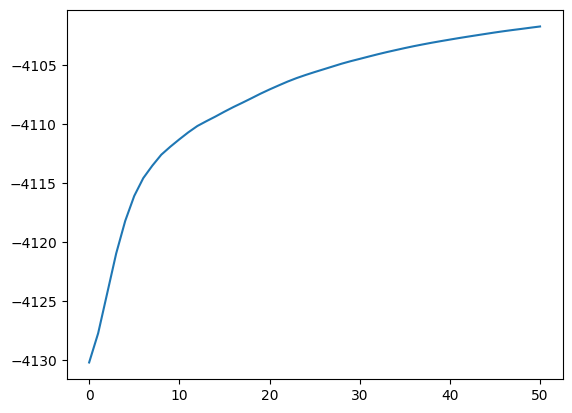

In [20]:
plt.figure()
plt.plot(np.arange(51), params['loglik_trajectory'])

# Optimization

### Simple model on miRNA alignments:

In [13]:
true_match = 1
true_mismatch = -1
true_gapopen = -1.2
true_gapext = -0.1

In [14]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.match = true_match
aligner.mismatch = true_mismatch

In [15]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

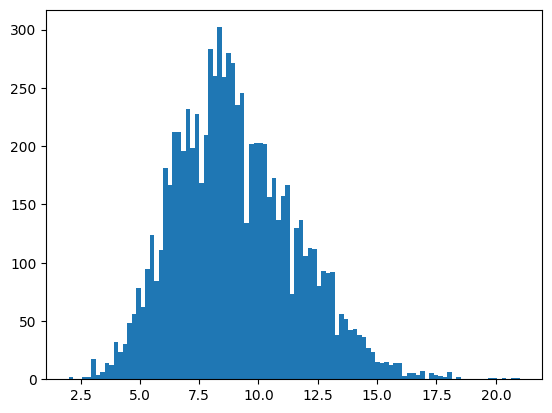

In [16]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [17]:
true_alpha = -9

In [18]:
logit_scores = logit_partial_scores(scores, true_alpha)

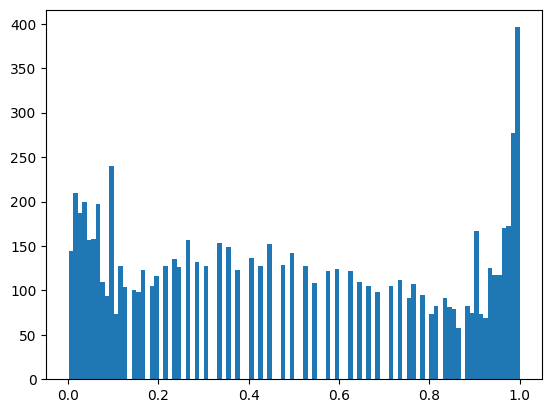

In [19]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [20]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores

In [21]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -10002.78024009512
True LogL: -3304.8802400951217


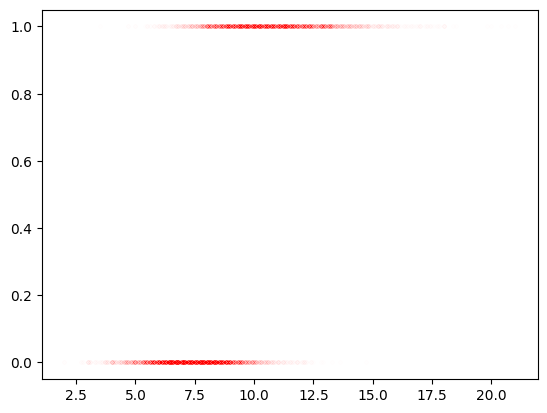

In [27]:
plt.figure()
plt.plot(scores, labels, 'r.', alpha=0.005)

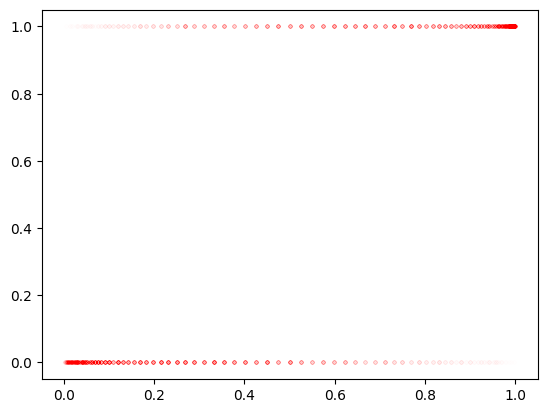

In [26]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.005)

In [28]:
const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [31]:
NITER = 10

In [32]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    verbose=False, max_iter=NITER,
                    num_threads = 16)

In [33]:
print(params['final_loglik'], params['loglik_expectation_trajectory'][-1], params['loglik_sd_trajectory'][-1])

-3324.1271171463504 -3413.847865074126 54.11689986311667


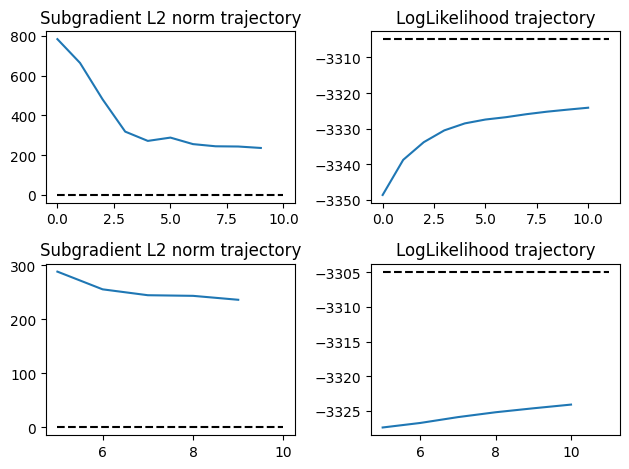

In [35]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [ ]:
print(true_match, params['match_score'])
print(true_mismatch, params['mismatch_score'])
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])

### General matrix, affine gap penalty

In [36]:
true_gapopen = -1.2
true_gapext = -0.1
true_substitution = substitution_matrices.Array(alphabet='ACTG', 
                                          data=np.array([
                                              [1, -0.3, -1, -0.8], 
                                              [-0.6, 1.2, -0.3, -1], 
                                              [-1.2, -0.4, 1, -0.8], 
                                              [-0.4, -1.4, -0.9, 1.3]]))

In [37]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.substitution_matrix = true_substitution

In [38]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

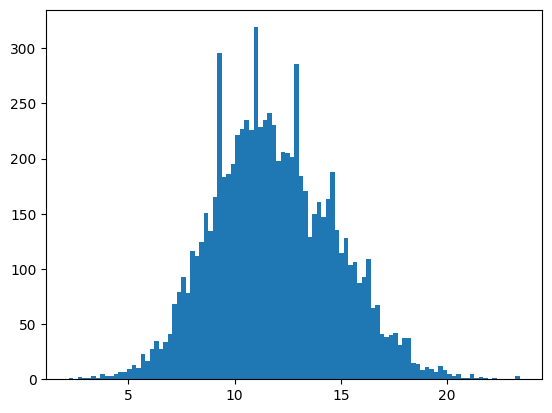

In [39]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [40]:
true_alpha = -12
logit_scores = logit_partial_scores(scores, true_alpha)

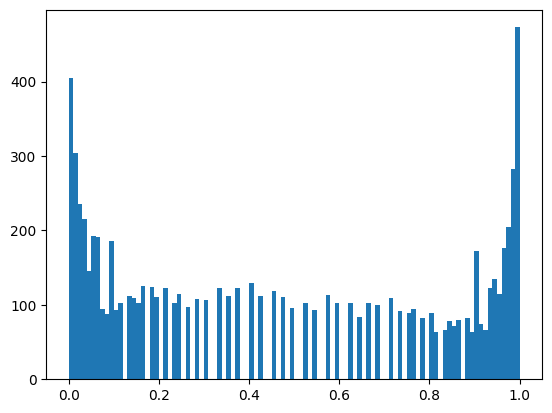

In [41]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [42]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -11654.43085041492
True LogL: -2968.130850414926


In [43]:
const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00005, power=0.5, burnin=0)
powerstep = create_powerstep(0.00002, power=-0.1, burnin=0)

In [44]:
NITER = 500

In [93]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=powerstep,
                    aligner_mode='local',
                    substitution_mode='general',
                    gap_mode='affine', 
                    verbose=False, max_iter=NITER,
                    num_threads = 24)

In [94]:
print(params['final_loglik'], params['loglik_expectation_trajectory'][-1], params['loglik_sd_trajectory'][-1])

-3031.2279129547765 -3070.8881681585167 53.51769268588581


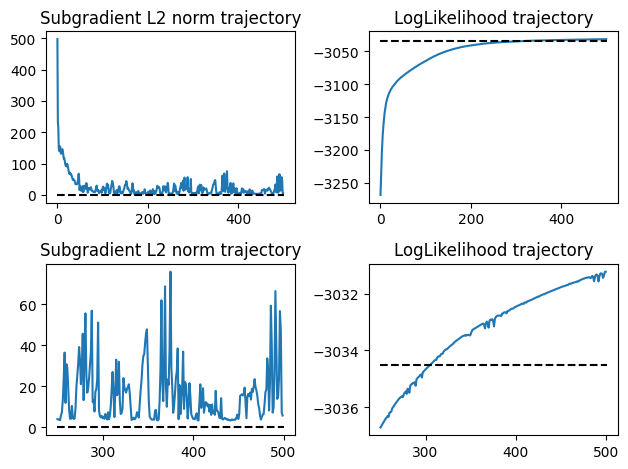

In [100]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')


plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [97]:
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])
true_subs_vector = []
param_subs_vector = []
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        true_v = true_substitution[char1, char2]
        true_subs_vector.append(true_v)
        estim_v = params['substitution_matrix'][char1, char2]
        param_subs_vector.append(estim_v)
        print(char1, char2, true_v, estim_v)
        
print(np.corrcoef(true_subs_vector, param_subs_vector))

-1.2 -1.1799130474232646
-0.1 -0.09347764772383456
-12 -11.45559397301257
A A 1.0 0.9745830401259133
A C -0.3 -0.35881951303911647
A T -1.0 -0.8978635712520299
A G -0.8 -0.8301449209991598
C A -0.6 -0.5976472033477707
C C 1.2 1.1521679388153905
C T -0.3 -0.33768907735804904
C G -1.0 -0.9211226702143284
T A -1.2 -1.072572959641055
T C -0.4 -0.38380783976995714
T T 1.0 0.9607359084379549
T G -0.8 -0.6833719967944281
G A -0.4 -0.40282491196243836
G C -1.4 -0.9321405020817473
G T -0.9 -0.9557448895598948
G G 1.3 1.2407179487501145
[[1.         0.99143702]
 [0.99143702 1.        ]]


### Symmetric matrix on protein alignments:

In [236]:
blosum62 = substitution_matrices.load('BLOSUM62')

In [237]:
blosum62 /= np.sqrt(np.sum(blosum62**2))

In [243]:
aligner = PairwiseAligner()
aligner.mode = 'global'
aligner.substitution_matrix=blosum62
aligner.open_gap_score = -1
aligner.extend_gap_score = -0.1

In [244]:
test_aln = aligner.align('ATA', 'AA')
print(next(test_aln))
print(2*blosum62['A', 'A'] - 1, test_aln.score)
test_aln = aligner.align('ATTA', 'AA')
print(next(test_aln))
print(2*blosum62['A', 'A'] - 1 - 0.05, test_aln.score)

target            0 ATA 3
                  0 |-| 3
query             0 A-A 2

-0.866998755185649 -0.8669987551856488
target            0 ATTA 4
                  0 |--| 4
query             0 A--A 2

-0.916998755185649 -0.9669987551856489


In [245]:
scores = np.array([aligner.score(a, b) for a, b in zip(human_list, chick_list)])

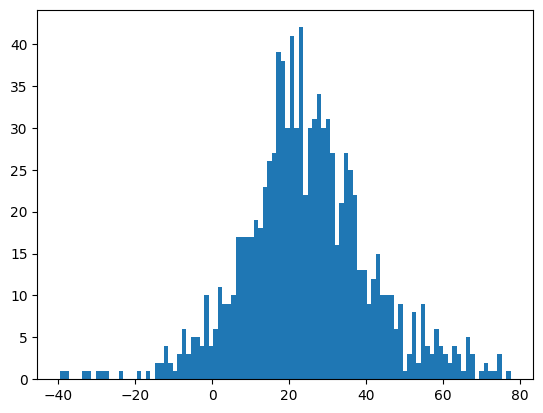

In [246]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [217]:
print(next(aligner.align(human_list[0], chick_list[0])))

XP_047282         0 -----------------------MDADMDYERPNVETIKCVVVGDNAVGKTRLICARACN
                  0 -----------------------||.||||||||||||||||||||||||||||||||||
XP_001232         0 MDPKGKGSPTVTMTALARSLSQLMDSDMDYERPNVETIKCVVVGDNAVGKTRLICARACN

XP_047282        37 TTLTQYQLLATHVPTVWAIDQYRVCQEVLERSRDVVDEVSVSLRLWDTFGDHHKDRRFAY
                 60 .||||||||||||||||||||||||||||||||||||.||||||||||||||||||||||
XP_001232        60 ATLTQYQLLATHVPTVWAIDQYRVCQEVLERSRDVVDDVSVSLRLWDTFGDHHKDRRFAY

XP_047282        97 GRSDVVVLCFSIANPNSLNHVKSMWYPEIKHFCPRTPVILVGCQLDLRYADLEAVNRARR
                120 ||||||||||||||||||.|||.||||||||||||.||||||||||||||||||||||||
XP_001232       120 GRSDVVVLCFSIANPNSLHHVKTMWYPEIKHFCPRAPVILVGCQLDLRYADLEAVNRARR

XP_047282       157 PLARPIKRGDILPPEKGREVAKELGLPYYETSVFDQFGIKDVFDNAIRAALISRRHLQFW
                180 |||||||...|||||||||||||||.|||||||..|||||||||||||||||||||||||
XP_001232       180 PLARPIKPNEILPPEKGREVAKELGIPYYETSVVAQFGIKDVFDNAIRAALISRRHLQFW

XP_047282       217 KSHL

In [247]:
logit_scores = logit_partial_scores(scores, -20)

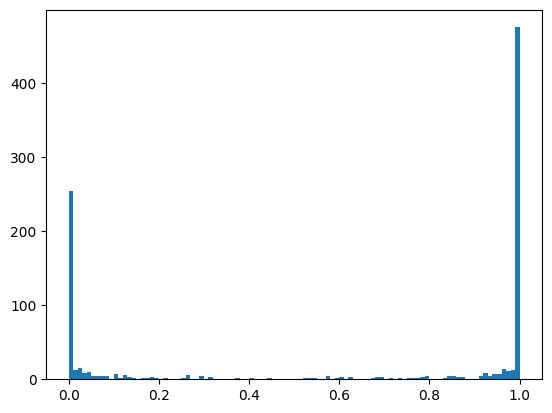

In [248]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

Expectation check:

In [249]:
logL_distribution = []
for _ in range(5000):
    labels = rd.rand(len(human_list))
    labels = labels <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    logL_distribution.append(true_logL)

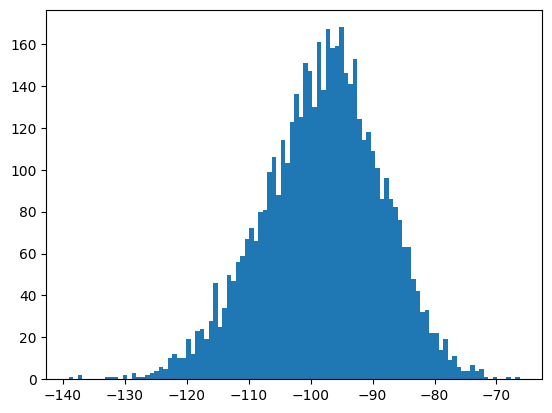

In [250]:
plt.figure()
plt.hist(logL_distribution, bins=100)
plt.show()

In [251]:
EL = 0 
VL = 0
for ls in logit_scores:
    if 1e-24 < ls < 1-1e-24:
        EL += ls*np.log(ls) + (1-ls)*np.log(1-ls)
        VL += ls*(1-ls)*(np.log(ls)**2 + np.log(1-ls)**2) # Incorrect
SDL = np.sqrt(VL)

In [252]:
print('Expected LogL:', EL)
print('Average LogL:', np.mean(logL_distribution))
print('STD LogL:', SDL)
print('Sample STD:', np.std(logL_distribution))

Expected LogL: -98.04969106774429
Average LogL: -98.12415007995585
STD LogL: 10.721755368499657
Sample STD: 9.61222701141045


Fitting:

In [253]:
labels = rd.rand(len(human_list))
labels = labels <= logit_scores

In [254]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [255]:
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -4223.962017569524
True LogL: -105.73115370455


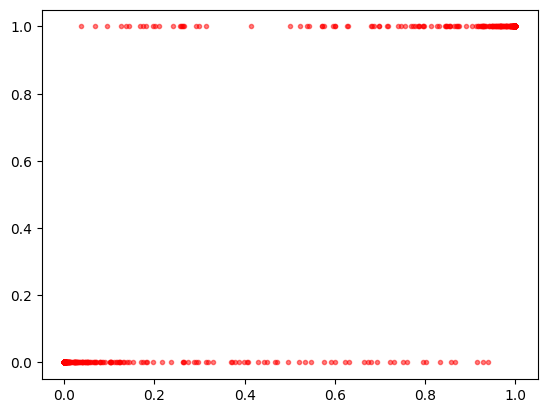

In [256]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.5)

In [257]:
const_step = create_constant_step(0.0000001)
# powerstep = create_powerstep(0.0000001, power=0.5, burnin=0)
powerstep = create_powerstep(0.0000001, power=-0.5, burnin=0)

In [258]:
NITER = 50

In [259]:
params = estimalign(human_list, chick_list, labels, 
                    stepfunction=const_step,
                    aligner_mode='global',
                    verbose=True, max_iter=NITER,
                    num_threads = 16)

Alphabet:
NSEXTYVGQADHPFCIMRLKW
Initial parameters:
{'alpha': -6.9547535274755035, 'match_score': 0.026332097125543484, 'mismatch_score': 0.009105054808583398, 'open_gap_score': 0.02263860749401156, 'extend_gap_score': -0.024652780593130683, 'substitution_matrix': Array([[0.0263321 , 0.00910505, 0.00910505, 0.00910505, 0.00910505,
        0.00910505, 0.00910505, 0.00910505, 0.00910505, 0.00910505,
        0.00910505, 0.00910505, 0.00910505, 0.00910505, 0.00910505,
        0.00910505, 0.00910505, 0.00910505, 0.00910505, 0.00910505,
        0.00910505],
       [0.00910505, 0.0263321 , 0.00910505, 0.00910505, 0.00910505,
        0.00910505, 0.00910505, 0.00910505, 0.00910505, 0.00910505,
        0.00910505, 0.00910505, 0.00910505, 0.00910505, 0.00910505,
        0.00910505, 0.00910505, 0.00910505, 0.00910505, 0.00910505,
        0.00910505],
       [0.00910505, 0.00910505, 0.0263321 , 0.00910505, 0.00910505,
        0.00910505, 0.00910505, 0.00910505, 0.00910505, 0.00910505,
        0.009

/home/mciach/Projects/EstimAlign/src/logit_link.py:29: RuntimeWarning: divide by zero encountered in log
  logl += np.log(1-p)
/home/mciach/Py3Env/lib/python3.10/site-packages/scipy/optimize/_linesearch.py:141: RuntimeWarning: invalid value encountered in scalar subtract
  alpha1 = min(1.0, 1.01*2*(phi0 - old_phi0)/derphi0)
/home/mciach/Py3Env/lib/python3.10/site-packages/scipy/optimize/_linesearch.py:390: RuntimeWarning: invalid value encountered in scalar subtract
  alpha1 = min(1.0, 1.01*2*(phi0 - old_phi0)/derphi0)
/home/mciach/Projects/EstimAlign/src/logit_link.py:29: RuntimeWarning: divide by zero encountered in log
  logl += np.log(1-p)


Current alpha: -6.9547535274755035
Current logL: -inf
Updated alpha: -6.9547535274755035
Updated logL: -inf
New subgradient:
{'Substitutions': Array([[-6.57796176e+02, -3.78664854e+01, -4.86947264e+01,
         0.00000000e+00, -3.68851124e+01, -2.39974342e+01,
        -3.71533809e+01, -3.31805837e+01, -2.56441718e+01,
        -3.19488298e+01, -3.49607974e+01, -2.09842989e+01,
        -3.43430069e+01, -1.59667160e+01, -1.33385924e+01,
        -2.89933711e+01, -1.89602896e+01, -2.58641075e+01,
        -4.85937061e+01, -4.12360153e+01, -9.99248567e+00],
       [-5.37574957e+01, -3.13835886e+03, -9.68292636e+01,
         0.00000000e+00, -6.27147471e+01, -4.79593349e+01,
        -7.29261541e+01, -8.09006170e+01, -4.48480205e+01,
        -9.37388969e+01, -6.48884673e+01, -3.59398947e+01,
        -5.52313509e+01, -4.93132317e+01, -1.49309501e+01,
        -4.50976328e+01, -3.12714587e+01, -6.37904623e+01,
        -1.11763252e+02, -7.69150141e+01, -1.38973357e+01],
       [-4.38243800e+01, -8.0

Current alpha: -6.9547535274755035
Current logL: -5469.564822665482
Updated alpha: -19.36421493220459
Updated logL: -2186.3230549354294
New subgradient:
{'Substitutions': Array([[-2.23653478e+02, -1.36887866e+01, -1.46189391e+01,
         0.00000000e+00, -9.34455753e+00, -1.04271910e+01,
        -1.41967550e+01, -1.01837329e+01, -8.89066173e+00,
        -1.64136338e+01, -1.42150105e+01, -1.24347171e+01,
        -8.49752389e+00, -8.79776667e+00, -1.04427291e+01,
        -1.31289499e+01, -9.50154648e+00, -1.43115958e+01,
        -1.04590372e+01, -1.51929305e+01, -6.88706525e+00],
       [-2.03331727e+01, -8.32169992e+02, -1.76757033e+01,
         0.00000000e+00, -8.15173468e+00, -1.02822589e+01,
        -1.32371119e+01, -1.42956402e+01, -1.13337272e+01,
        -8.11130545e+00, -1.10329231e+01, -1.55323377e+01,
        -8.16945823e+00, -1.49473495e+01, -1.19555439e+01,
        -1.39297077e+01, -1.43486562e+01, -1.21854223e+01,
        -7.87972059e+00, -1.06974087e+01, -8.50088981e+00],
 

Current alpha: -19.36421493220459
Current logL: -2110.589595573869
Updated alpha: -18.029017162620686
Updated logL: -2058.1326944297894
New subgradient:
{'Substitutions': Array([[-2.29372047e+02, -1.10029758e+01, -1.42584573e+01,
         0.00000000e+00, -1.06610947e+01, -1.24651091e+01,
        -1.86102532e+01, -9.51170920e+00, -9.60014075e+00,
        -1.57620274e+01, -1.68041633e+01, -1.15316851e+01,
        -1.03465751e+01, -7.91752541e+00, -1.19175498e+01,
        -1.28395938e+01, -1.03463757e+01, -1.35077431e+01,
        -9.00136475e+00, -1.58044670e+01, -7.11182166e+00],
       [-1.64060896e+01, -8.43034146e+02, -1.82973346e+01,
         0.00000000e+00, -9.52229887e+00, -9.18066932e+00,
        -1.39038698e+01, -1.63195101e+01, -1.03589500e+01,
        -8.79200629e+00, -1.40740445e+01, -1.60583699e+01,
        -8.85142244e+00, -1.34824613e+01, -1.40777014e+01,
        -1.40313405e+01, -1.66779276e+01, -1.28249208e+01,
        -8.66131087e+00, -1.07155468e+01, -9.94968967e+00],
 

...

Current alpha: -12.204389979839567
Current logL: -955.1854021317048
Updated alpha: -11.315611508326434
Updated logL: -918.3681252091072
New subgradient:
{'Substitutions': Array([[ 5.48218117e+02, -3.15490897e+01, -3.15792926e+01,
         0.00000000e+00, -5.00138912e+01, -1.05201460e+01,
        -2.64033733e+01, -2.69815091e+01, -3.60151540e+01,
        -1.52487310e+01, -2.56946290e+01, -1.81984926e+01,
        -3.07185521e+01, -1.35850682e+01, -2.08767396e+01,
        -2.34128290e+01, -1.43448427e+01, -2.61275356e+01,
        -4.00557505e+01, -2.42033242e+01, -3.69608773e+00],
       [-5.55045818e+01, -1.20299296e+03, -6.32564046e+01,
         0.00000000e+00, -6.73310866e+01, -3.00555561e+01,
        -3.91542736e+01, -4.72145888e+01, -5.05333279e+01,
        -6.42433326e+01, -6.02376659e+01, -4.27794132e+01,
        -4.63675139e+01, -3.72618301e+01, -4.11371442e+01,
        -3.91235932e+01, -3.79504435e+01, -4.60243178e+01,
        -6.56122525e+01, -6.79654910e+01, -3.16216486e+01],
 

Current alpha: -11.315611508326434
Current logL: -801.0218907338874
Updated alpha: -10.751809779031777
Updated logL: -785.568488779142
New subgradient:
{'Substitutions': Array([[ 4.58266423e+02, -1.82138644e+02, -9.50411591e+01,
         0.00000000e+00, -1.03051050e+02, -3.19709035e+01,
        -6.76614820e+01, -9.54541429e+01, -7.29958383e+01,
        -6.76769097e+01, -1.35401978e+02, -6.29778942e+01,
        -8.59915628e+01, -3.36357344e+01, -4.27748459e+01,
        -5.26745465e+01, -2.95261305e+01, -9.19976920e+01,
        -6.99905689e+01, -9.93248479e+01, -1.37373180e+01],
       [-1.97074828e+02, -1.19851425e+03, -1.75400897e+02,
         0.00000000e+00, -2.79680074e+02, -7.01018768e+01,
        -1.75516371e+02, -1.77001006e+02, -1.37352473e+02,
        -3.07796282e+02, -1.45300390e+02, -7.46897261e+01,
        -2.49533209e+02, -8.88547481e+01, -7.93104504e+01,
        -1.04380555e+02, -7.16223225e+01, -1.63517510e+02,
        -1.47434338e+02, -1.71099572e+02, -3.58612937e+01],
  

Current alpha: -10.751809779031777
Current logL: -743.599103861766
Updated alpha: -10.524002060632354
Updated logL: -741.0578273897394
New subgradient:
{'Substitutions': Array([[  428.01018279,  -168.08832759,   -99.18108896,     0.        ,
         -106.03722962,   -30.61138242,   -64.00935678,   -91.02903838,
          -92.997275  ,   -65.48305495,   -94.72630405,   -48.75380872,
          -92.98577252,   -33.28075906,   -37.07559724,   -55.5347799 ,
          -30.6500486 ,   -95.07321313,   -86.04929347,   -93.90907724,
          -11.70834023],
       [ -186.76378995, -1167.09010064,  -231.63901136,     0.        ,
         -259.86943179,   -69.75766616,  -165.65613634,  -177.33361456,
         -144.73035047,  -247.94881309,  -151.0848717 ,   -89.65292022,
         -193.89496804,   -87.36524576,   -75.85684911,  -109.68806611,
          -68.44147713,  -160.26962889,  -214.78916657,  -209.36635558,
          -37.44666245],
       [ -107.05280295,  -209.5369575 , -1134.18120149,     

Current alpha: -10.524002060632354
Current logL: -706.8653954360425
Updated alpha: -10.321618514882513
Updated logL: -704.8507777192223


KeyboardInterrupt: 

In [29]:
print(params['final_loglik'], params['loglik_expectation_trajectory'][-1], params['loglik_sd_trajectory'][-1])

-133.71954960317976 -175.04414499148095 13.484850714883319


In [30]:
print(max(params['loglik_trajectory']))

-133.71954960317976


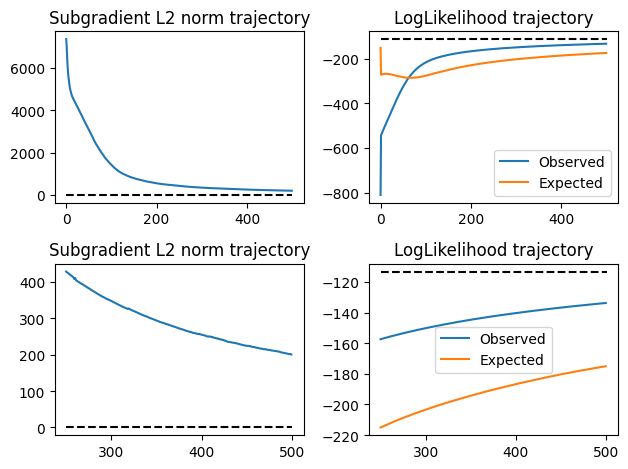

In [32]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot(np.arange(NITER+1), params['loglik_expectation_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')
plt.legend(['Observed', 'Expected'])

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_expectation_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')
plt.legend(['Observed', 'Expected'])

plt.tight_layout()

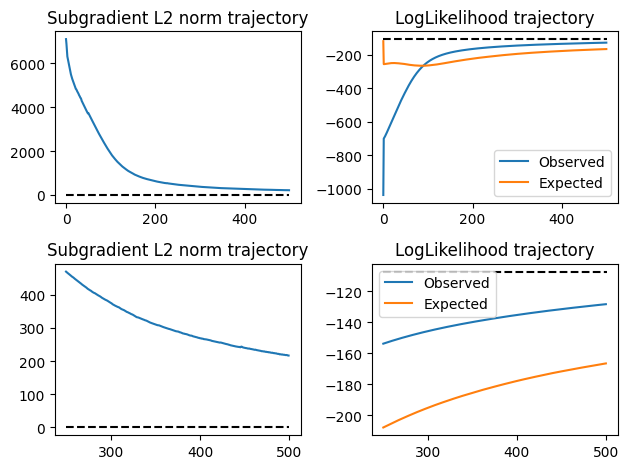

In [92]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot(np.arange(NITER+1), params['loglik_expectation_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')
plt.legend(['Observed', 'Expected'])

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_expectation_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')
plt.legend(['Observed', 'Expected'])

plt.tight_layout()

In [94]:
print(params['open_gap_score'], aligner.open_gap_score)
print(params['extend_gap_score'], aligner.extend_gap_score)

-0.18054998513261955 -1.0
-0.035937991187379434 -0.05


In [95]:
params['alpha']

-11.372369171980543

In [96]:
blosum_vs_mine = []
for char1 in params['substitution_matrix'].alphabet:
    for char2 in params['substitution_matrix'].alphabet:
        if char1 != 'N' and char2 != 'N':
            blosum_vs_mine.append([char1, char2,blosum62[char1, char2], params['substitution_matrix'][char1, char2]])

In [97]:
print('Blosum, Mine')
for i in rd.choice(len(blosum_vs_mine), 10, replace=False):
    print(blosum_vs_mine[i])

Blosum, Mine
['E', 'X', -0.01662515560179388, 0.015886711390326522]
['K', 'Q', 0.01662515560179388, 0.008296680852470135]
['A', 'K', -0.01662515560179388, -0.010789978971235445]
['X', 'W', -0.03325031120358776, 0.015886711390326522]
['H', 'Q', 0.0, -0.003970359129315122]
['F', 'G', -0.049875466805381644, 0.0035528961327452964]
['I', 'D', -0.049875466805381644, -0.000271979945830434]
['Q', 'I', -0.049875466805381644, 0.0019382077773239185]
['Q', 'X', -0.01662515560179388, 0.015886711390326522]
['E', 'G', -0.03325031120358776, -0.014114232172467697]


In [98]:
np.corrcoef([x[2] for x in blosum_vs_mine], [x[3] for x in blosum_vs_mine])

array([[1.        , 0.38562591],
       [0.38562591, 1.        ]])

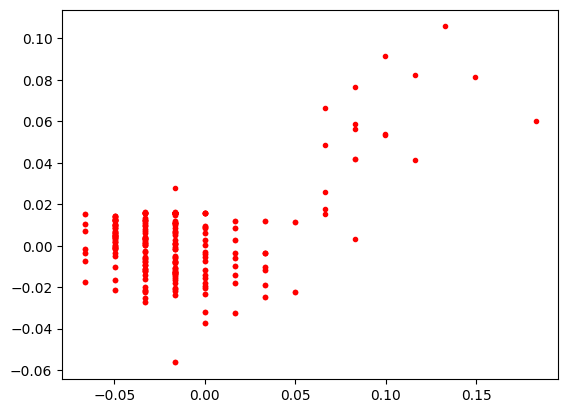

In [99]:
plt.figure()
plt.plot([x[2] for x in blosum_vs_mine], [x[3] for x in blosum_vs_mine], 'r.')